In [72]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [73]:
df = pd.read_table('quora_duplicate_questions.tsv')


In [74]:
df.sample(5)

,id,qid1,qid2,question1,question2,is_duplicate
387095,387095,76851,519400,What is Definition of Instrumentation?,What is biomedical instrumentation?,0
121776,121776,197264,197265,what is the procedure to apply government comp...,Can I do ms in physics after doing computer en...,0
34590,34590,63353,63354,Is it weird that I watch anime though I'm 21?,Is it weird that I watch anime though I am 21?,1
56089,56089,98774,98775,In what way a girl is inferior to her husband'...,What qualities does a girl want in her husband?,0
182966,182966,279901,279902,What is the history of the A Song of Ice and F...,What is the order of the books in the Song of ...,0


In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   id            404290 non-null  int64
 1   qid1          404290 non-null  int64
 2   qid2          404290 non-null  int64
 3   question1     404289 non-null  str  
 4   question2     404288 non-null  str  
 5   is_duplicate  404290 non-null  int64
dtypes: int64(4), str(2)
memory usage: 18.5 MB


In [76]:
df.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [77]:
df.duplicated().sum()

np.int64(0)

is_duplicate
0    255027
1    149263
Name: count, dtype: int64
is_duplicate
0    63.080215
1    36.919785
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

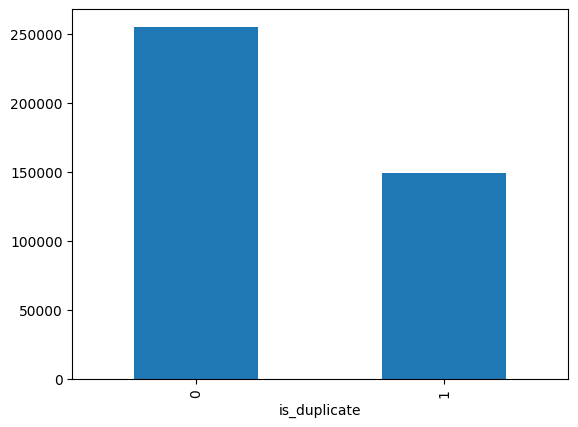

In [78]:
print(df['is_duplicate'].value_counts())
print((df['is_duplicate'].value_counts()/df['is_duplicate'].count())*100)
df['is_duplicate'].value_counts().plot(kind='bar')

In [80]:
# Repeated questions
quid = pd.Series(df['qid1'].tolist() + df['qid2'].tolist())
print('Number of unique questions in question1: ', np.unique(quid).shape[0]) 
x = quid.value_counts()>1
print('Number of questions that are repeated: ', x[x].shape[0])

Number of unique questions in question1:  537933
Number of questions that are repeated:  111780


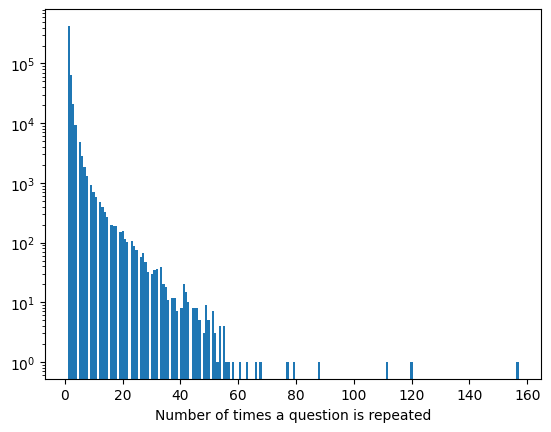

In [83]:
plt.hist(quid.value_counts(), bins=200)
plt.xlabel('Number of times a question is repeated')
plt.yscale('log')
plt.show()